# Liver patient prediction

## Data Preprocessing

In [28]:
import pandas as pd

data = pd.read_csv('../data/cleaned_data.csv')
data

,Unnamed: 0,age,gender,tbilirubin,dbilirubin,alp,alt,ast,tpro,albumin,agratio,target
0,0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...,...
578,578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [29]:
data.drop('Unnamed: 0',axis=1,inplace=True)
data

,age,gender,tbilirubin,dbilirubin,alp,alt,ast,tpro,albumin,agratio,target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [30]:
data['gender'] = data['gender'].map({"Female":0,"Male":1})

In [31]:
data

,age,gender,tbilirubin,dbilirubin,alp,alt,ast,tpro,albumin,agratio,target
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1
...,...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37,0
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00,1


In [32]:
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

### Outlier detection and removal

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
data.columns

Index(['age', 'gender', 'tbilirubin', 'dbilirubin', 'alp', 'alt', 'ast',
       'tpro', 'albumin', 'agratio', 'target'],
      dtype='str')

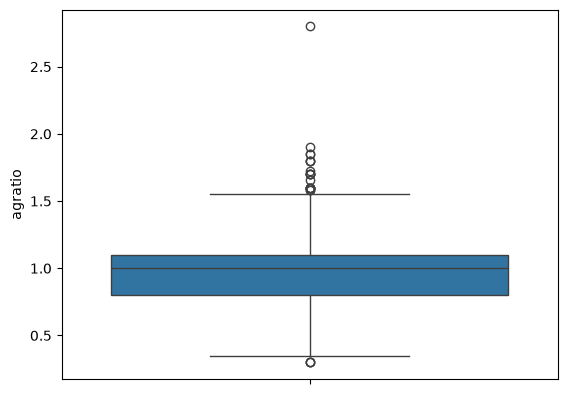

In [54]:
sns.boxplot(data['agratio'])
plt.show()

In [50]:
data = data.loc[data['ast']<700]

In [55]:
X = data.iloc[:,:-1]
y = data.iloc[:,-1]

### Oversampling

In [64]:
data['target'].value_counts()

target
1    352
0    166
Name: count, dtype: int64

In [65]:
from imblearn.over_sampling import SMOTE

smote = SMOTE()


In [66]:
smote.fit_resample(X,y)

(     age  gender  tbilirubin  dbilirubin  alp  alt  ast      tpro   albumin  \
 0     65       0    0.700000    0.100000  187   16   18  6.800000  3.300000   
 1     62       1   10.900000    5.500000  699   64  100  7.500000  3.200000   
 2     62       1    7.300000    4.100000  490   60   68  7.000000  3.300000   
 3     58       1    1.000000    0.400000  182   14   20  6.800000  3.400000   
 4     72       1    3.900000    2.000000  195   27   59  7.300000  2.400000   
 ..   ...     ...         ...         ...  ...  ...  ...       ...       ...   
 699   50       0    0.957555    0.286333  176   25   50  5.902887  3.016554   
 700   60       1    2.148792    0.972426  272   45   52  6.135452  2.919695   
 701   18       0    0.700000    0.177329  143   21   33  7.290683  3.990683   
 702   38       0    2.600000    1.200000  410   59   57  5.600000  3.000000   
 703   35       0    1.198396    0.399198  358  159   90  8.292784  4.395189   
 
       agratio  
 0    0.900000  
 1  

In [67]:
y.value_counts()

target
1    352
0    352
Name: count, dtype: int64

### Scaling

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=45)

In [69]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [88]:
import joblib

joblib.dump(scaler,'scaler.pkl')

['scaler.pkl']

## Model Building

In [74]:
from sklearn.linear_model import LogisticRegression

model1 = LogisticRegression()

model1.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [75]:
y_pred1 = model1.predict(X_test)

In [76]:
y_pred1

array([0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0])

In [98]:
y_pred12 = (model1.predict_proba(X_test)[:,1]>0.459).astype(int)

In [ ]:
sns.regplot(data)

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred1))

              precision    recall  f1-score   support

           0       0.66      0.88      0.75        72
           1       0.80      0.54      0.64        69

    accuracy                           0.71       141
   macro avg       0.73      0.71      0.70       141
weighted avg       0.73      0.71      0.70       141



In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred12))

              precision    recall  f1-score   support

           0       0.68      0.75      0.72        72
           1       0.71      0.64      0.67        69

    accuracy                           0.70       141
   macro avg       0.70      0.69      0.69       141
weighted avg       0.70      0.70      0.69       141



In [100]:
print(model1.score(X_train,y_train))
print(model1.score(X_test,y_test))

0.6820603907637656
0.7092198581560284


In [89]:
joblib.dump(model1,'liverappolo.pkl')

['liverappolo.pkl']

In [102]:
from sklearn.ensemble import GradientBoostingClassifier

model2 = GradientBoostingClassifier()

model2.fit(X_train,y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [103]:
y_pred2 = model2.predict(X_test)

In [122]:
y_pred22 = (model2.predict_proba(X_test)[:,1]>0.37).astype(int)

In [104]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred2))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77        72
           1       0.76      0.74      0.75        69

    accuracy                           0.76       141
   macro avg       0.76      0.76      0.76       141
weighted avg       0.76      0.76      0.76       141



In [123]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred22))

              precision    recall  f1-score   support

           0       0.87      0.62      0.73        72
           1       0.70      0.90      0.78        69

    accuracy                           0.76       141
   macro avg       0.78      0.76      0.76       141
weighted avg       0.78      0.76      0.75       141



In [124]:
joblib.dump(y_pred22,'liverzeus.pkl')

['liverzeus.pkl']